# Regressão Logística para Detecção de Alzheimer

## Objetivo
Este notebook implementa um **classificador de Regressão Logística** otimizado para classificação binária, com o objetivo de determinar se um paciente tem Alzheimer ou não.

## Sobre Regressão Logística
A Regressão Logística é um algoritmo linear que estima a **probabilidade** de uma amostra pertencer a uma classe usando a função sigmoide. Apesar do nome, é um algoritmo de **classificação**, não de regressão.

### Características da Regressão Logística:
- **Interpretável**: Coeficientes indicam a importância de cada feature
- **Probabilístico**: Retorna probabilidades, não apenas classes
- **Eficiente**: Treino rápido, mesmo em grandes datasets
- **Linear**: Assume relação linear entre features e log-odds
- **Regularização**: L1 (Lasso), L2 (Ridge), ou Elastic Net

### A Função Sigmoide:
$$P(y=1|x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + ... + \beta_n x_n)}}$$

## Métricas Importantes para Diagnóstico Médico
- **Recall**: Capacidade de identificar corretamente os casos positivos
- **Precisão**: Proporção de diagnósticos positivos corretos
- **F1-Score**: Média harmônica entre precisão e recall
- **AUC-ROC**: Área sob a curva ROC

## 1. Importação das Bibliotecas

In [1]:
# ==============================================================================
# IMPORTAÇÃO DE BIBLIOTECAS
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression  # Regressão Logística
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_curve, 
    auc, 
    precision_recall_curve,
    accuracy_score,
    f1_score,
    recall_score,
    precision_score
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2. Carregamento e Exploração dos Dados

In [2]:
# ==============================================================================
# CARREGAMENTO DOS DADOS
# ==============================================================================

import os

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    csv_path = '/content/drive/MyDrive/alzheimers_disease_data.csv'
    print('Rodando no Google Colab')
except ImportError:
    print('Rodando localmente - Selecione o arquivo CSV')
    import tkinter as tk
    from tkinter import filedialog
    
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    
    csv_path = filedialog.askopenfilename(
        title='Selecione o arquivo alzheimers_disease_data.csv',
        filetypes=[('CSV files', '*.csv'), ('All files', '*.*')]
    )
    root.destroy()
    
    if not csv_path:
        raise FileNotFoundError('Nenhum arquivo selecionado!')

df = pd.read_csv(csv_path)

print(f'Dataset carregado com sucesso!')
print(f'Dimensões: {df.shape[0]} amostras x {df.shape[1]} features')

Rodando localmente - Selecione o arquivo CSV
Dataset carregado com sucesso!
Dimensões: 2149 amostras x 35 features


In [3]:
# ==============================================================================
# EXPLORAÇÃO INICIAL
# ==============================================================================

print("=" * 60)
print("PRIMEIRAS LINHAS DO DATASET")
print("=" * 60)
display(df.head())

print("\n" + "=" * 60)
print("INFORMAÇÕES DO DATASET")
print("=" * 60)
print(df.info())

PRIMEIRAS LINHAS DO DATASET


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid



INFORMAÇÕES DO DATASET
<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non

## 3. Pré-processamento dos Dados

In [4]:
# ==============================================================================
# PRÉ-PROCESSAMENTO
# ==============================================================================

colunas_remover = ['PatientID', 'DoctorInCharge']
df = df.drop(columns=colunas_remover)
print(f"Colunas removidas: {colunas_remover}")
print(f"Novas dimensões: {df.shape}")

print(f"\nValores nulos: {df.isnull().sum().sum()}")
print(f"Duplicatas: {df.duplicated().sum()}")

Colunas removidas: ['PatientID', 'DoctorInCharge']
Novas dimensões: (2149, 33)

Valores nulos: 0
Duplicatas: 0


## 4. Análise da Variável Alvo

Distribuição da variável alvo:
  - Saudável (0): 1389 (64.6%)
  - Com Alzheimer (1): 760 (35.4%)


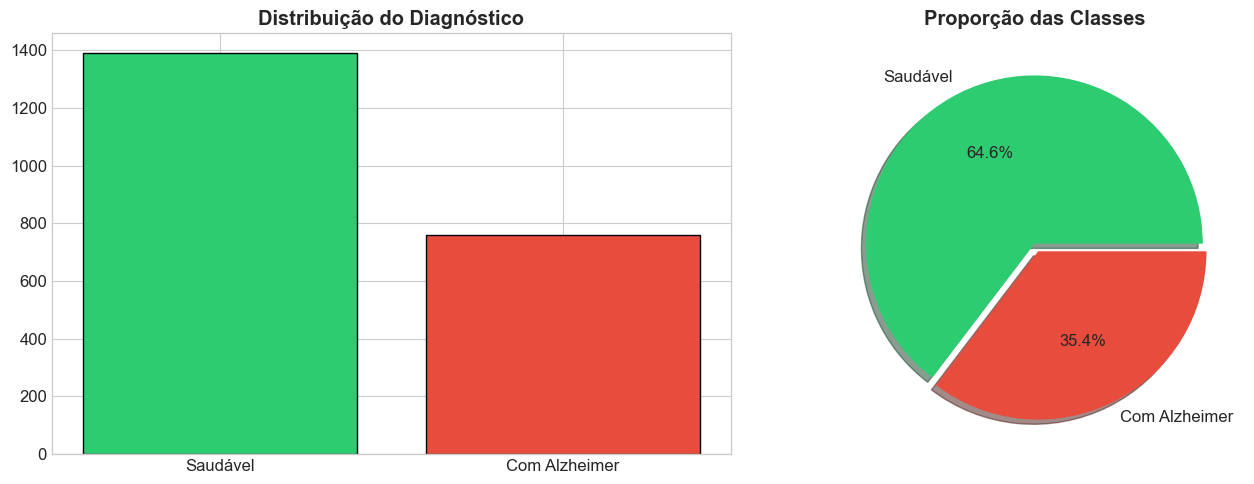

In [5]:
# ==============================================================================
# ANÁLISE DA VARIÁVEL ALVO
# ==============================================================================

contagem_classes = df['Diagnosis'].value_counts()
print("Distribuição da variável alvo:")
print(f"  - Saudável (0): {contagem_classes[0]} ({contagem_classes[0]/len(df)*100:.1f}%)")
print(f"  - Com Alzheimer (1): {contagem_classes[1]} ({contagem_classes[1]/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(['Saudável', 'Com Alzheimer'], 
            [contagem_classes[0], contagem_classes[1]], 
            color=colors, edgecolor='black')
axes[0].set_title('Distribuição do Diagnóstico', fontweight='bold')

axes[1].pie([contagem_classes[0], contagem_classes[1]], 
            labels=['Saudável', 'Com Alzheimer'],
            autopct='%1.1f%%', colors=colors, explode=(0, 0.05), shadow=True)
axes[1].set_title('Proporção das Classes', fontweight='bold')

plt.tight_layout()
plt.savefig('lr_distribuicao_classes.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Balanceamento e Preparação dos Dados

In [6]:
# ==============================================================================
# SEPARAÇÃO E BALANCEAMENTO
# ==============================================================================

X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_balanced, y_balanced = smote.fit_resample(X, y)

print(f"Após SMOTE: {len(y_balanced)} amostras")
print(f"  - Classe 0: {sum(y_balanced == 0)}")
print(f"  - Classe 1: {sum(y_balanced == 1)}")

Após SMOTE: 2778 amostras
  - Classe 0: 1389
  - Classe 1: 1389


In [7]:
# ==============================================================================
# DIVISÃO TREINO/TESTE E NORMALIZAÇÃO
# ==============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, 
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_balanced
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

# NORMALIZAÇÃO - Recomendado para Regressão Logística
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nNormalização aplicada (StandardScaler)")
print("  Melhora a convergência e permite interpretação dos coeficientes.")

feature_names = X.columns.tolist()

Treino: 2083 amostras
Teste: 695 amostras

Normalização aplicada (StandardScaler)
  Melhora a convergência e permite interpretação dos coeficientes.


## 6. Modelo Regressão Logística Base

In [8]:
# ==============================================================================
# MODELO BASE (PARÂMETROS PADRÃO)
# ==============================================================================

print("=" * 60)
print("MODELO REGRESSÃO LOGÍSTICA BASE")
print("=" * 60)

lr_base = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr_base.fit(X_train_scaled, y_train)

y_pred_base = lr_base.predict(X_test_scaled)
y_proba_base = lr_base.predict_proba(X_test_scaled)[:, 1]

acc_base = accuracy_score(y_test, y_pred_base)
prec_base = precision_score(y_test, y_pred_base)
rec_base = recall_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)

print(f"\nResultados do Modelo Base:")
print(f"  Acurácia:  {acc_base*100:.2f}%")
print(f"  Precisão:  {prec_base*100:.2f}%")
print(f"  Recall:    {rec_base*100:.2f}%")
print(f"  F1-Score:  {f1_base*100:.2f}%")

MODELO REGRESSÃO LOGÍSTICA BASE

Resultados do Modelo Base:
  Acurácia:  82.45%
  Precisão:  80.16%
  Recall:    86.17%
  F1-Score:  83.06%


## 7. Comparação de Tipos de Regularização

A regularização é essencial para evitar overfitting:
- **L1 (Lasso)**: Pode zerar coeficientes (seleção de features)
- **L2 (Ridge)**: Reduz coeficientes, mas não zera
- **Elastic Net**: Combinação de L1 e L2

COMPARAÇÃO DE TIPOS DE REGULARIZAÇÃO

Treinando com regularização L1...
  F1-Score: 83.06%
  Coeficientes zerados: 0/32

Treinando com regularização L2...
  F1-Score: 83.06%
  Coeficientes zerados: 0/32

Treinando com regularização ELASTICNET...
  F1-Score: 83.06%
  Coeficientes zerados: 0/32


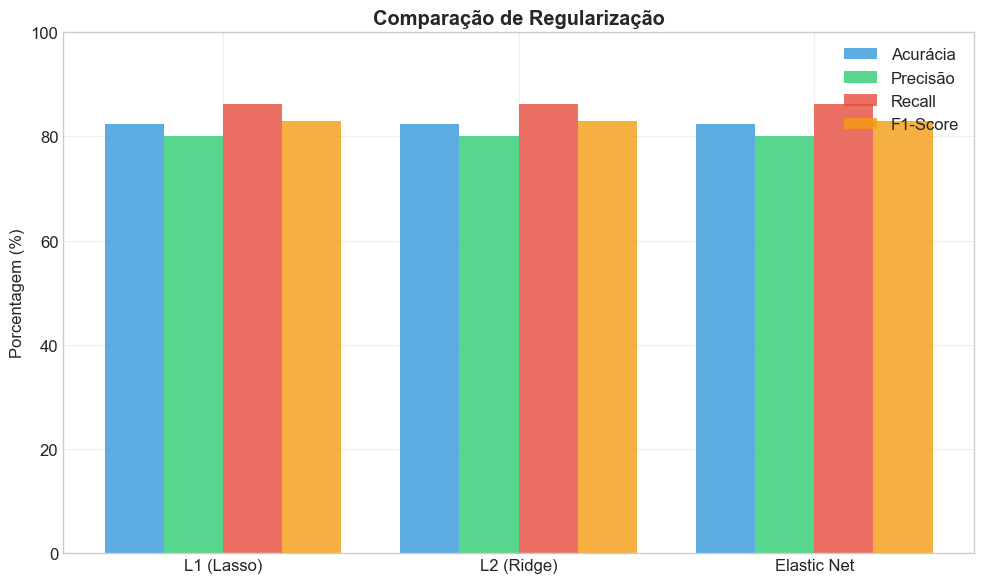

In [9]:
# ==============================================================================
# COMPARAÇÃO DE REGULARIZAÇÃO
# ==============================================================================

print("=" * 60)
print("COMPARAÇÃO DE TIPOS DE REGULARIZAÇÃO")
print("=" * 60)

penalties = [
    ('l1', 'saga'),
    ('l2', 'lbfgs'),
    ('elasticnet', 'saga')
]

resultados_reg = {}

for penalty, solver in penalties:
    print(f"\nTreinando com regularização {penalty.upper()}...")
    
    if penalty == 'elasticnet':
        lr = LogisticRegression(penalty=penalty, solver=solver, random_state=RANDOM_STATE, 
                                max_iter=1000, l1_ratio=0.5)
    else:
        lr = LogisticRegression(penalty=penalty, solver=solver, random_state=RANDOM_STATE, 
                                max_iter=1000)
    
    lr.fit(X_train_scaled, y_train)
    y_pred_r = lr.predict(X_test_scaled)
    
    # Contar coeficientes zerados (para L1)
    n_zero = np.sum(np.abs(lr.coef_[0]) < 1e-6)
    
    resultados_reg[penalty] = {
        'accuracy': accuracy_score(y_test, y_pred_r),
        'precision': precision_score(y_test, y_pred_r),
        'recall': recall_score(y_test, y_pred_r),
        'f1': f1_score(y_test, y_pred_r),
        'coef_zerados': n_zero
    }
    
    print(f"  F1-Score: {resultados_reg[penalty]['f1']*100:.2f}%")
    print(f"  Coeficientes zerados: {n_zero}/{len(feature_names)}")

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(penalties))
width = 0.2

metrics = ['accuracy', 'precision', 'recall', 'f1']
colors_bar = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
labels = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']

for i, (metric, color, label) in enumerate(zip(metrics, colors_bar, labels)):
    valores = [resultados_reg[p[0]][metric]*100 for p in penalties]
    ax.bar(x + i*width, valores, width, label=label, color=color, alpha=0.8)

ax.set_ylabel('Porcentagem (%)')
ax.set_title('Comparação de Regularização', fontweight='bold')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(['L1 (Lasso)', 'L2 (Ridge)', 'Elastic Net'])
ax.legend()
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lr_comparacao_regularizacao.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. GridSearch para Otimização

In [10]:
# ==============================================================================
# GRIDSEARCH PARA OTIMIZAÇÃO
# ==============================================================================

print("=" * 60)
print("GRIDSEARCH - OTIMIZAÇÃO DE HIPERPARÂMETROS")
print("=" * 60)

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Força da regularização (inverso)
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': [None, 'balanced']
}

print("\nGrade de hiperparâmetros:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("\nExecutando GridSearch...")
grid_search.fit(X_train_scaled, y_train)

print(f"\n" + "=" * 60)
print("MELHORES HIPERPARÂMETROS ENCONTRADOS:")
print("=" * 60)
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nMelhor F1-Score (CV): {grid_search.best_score_*100:.2f}%")

GRIDSEARCH - OTIMIZAÇÃO DE HIPERPARÂMETROS

Grade de hiperparâmetros:
  C: [0.001, 0.01, 0.1, 1, 10, 100]
  penalty: ['l1', 'l2']
  solver: ['liblinear', 'saga']
  class_weight: [None, 'balanced']

Executando GridSearch...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

MELHORES HIPERPARÂMETROS ENCONTRADOS:
  C: 0.1
  class_weight: None
  penalty: l2
  solver: liblinear

Melhor F1-Score (CV): 81.90%


## 9. Modelo Final Otimizado

In [11]:
# ==============================================================================
# MODELO FINAL OTIMIZADO
# ==============================================================================

print("=" * 60)
print("AVALIAÇÃO DO MODELO REGRESSÃO LOGÍSTICA OTIMIZADO")
print("=" * 60)

lr_otimizado = grid_search.best_estimator_

y_pred = lr_otimizado.predict(X_test_scaled)
y_proba = lr_otimizado.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nMétricas no Conjunto de Teste:")
print(f"  Acurácia:  {accuracy*100:.2f}%")
print(f"  Precisão:  {precision*100:.2f}%")
print(f"  Recall:    {recall*100:.2f}%")
print(f"  F1-Score:  {f1*100:.2f}%")

print("\n" + "=" * 60)
print("RELATÓRIO DE CLASSIFICAÇÃO DETALHADO")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Saudável', 'Alzheimer']))

AVALIAÇÃO DO MODELO REGRESSÃO LOGÍSTICA OTIMIZADO

Métricas no Conjunto de Teste:
  Acurácia:  82.30%
  Precisão:  80.11%
  Recall:    85.88%
  F1-Score:  82.89%

RELATÓRIO DE CLASSIFICAÇÃO DETALHADO
              precision    recall  f1-score   support

    Saudável       0.85      0.79      0.82       348
   Alzheimer       0.80      0.86      0.83       347

    accuracy                           0.82       695
   macro avg       0.82      0.82      0.82       695
weighted avg       0.82      0.82      0.82       695



## 10. Comparação: Base vs Otimizado

COMPARAÇÃO: MODELO BASE vs MODELO OTIMIZADO

Métrica         Base                 Otimizado            Melhoria       
----------------------------------------------------------------------
Acurácia                    82.45%             82.30%        -0.14%
Precisão                    80.16%             80.11%        -0.05%
Recall                      86.17%             85.88%        -0.29%
F1-Score                    83.06%             82.89%        -0.16%


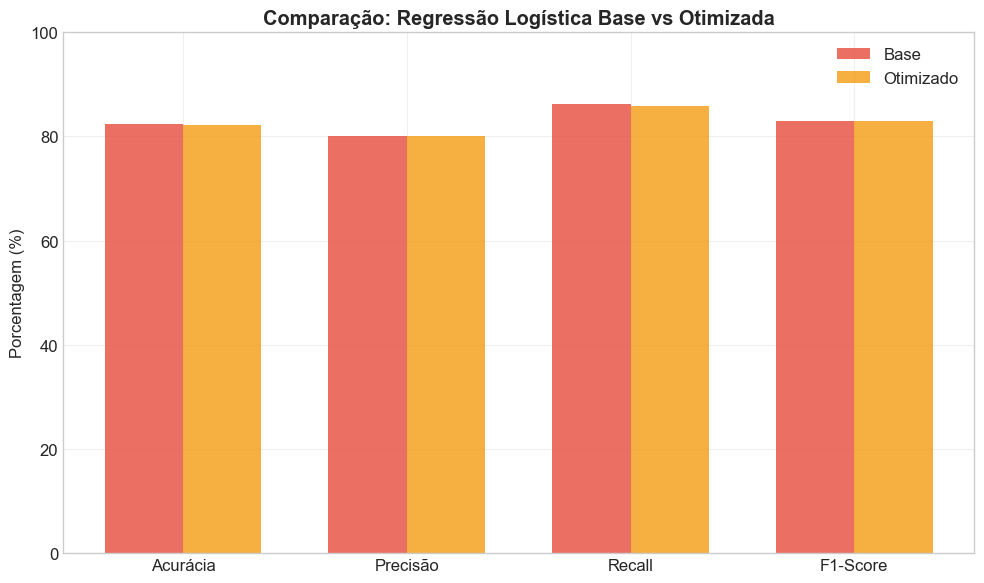

In [12]:
# ==============================================================================
# COMPARAÇÃO BASE vs OTIMIZADO
# ==============================================================================

print("=" * 70)
print("COMPARAÇÃO: MODELO BASE vs MODELO OTIMIZADO")
print("=" * 70)

print(f"\n{'Métrica':<15} {'Base':<20} {'Otimizado':<20} {'Melhoria':<15}")
print("-" * 70)
print(f"{'Acurácia':<15} {acc_base*100:>17.2f}% {accuracy*100:>17.2f}% {(accuracy-acc_base)*100:>+12.2f}%")
print(f"{'Precisão':<15} {prec_base*100:>17.2f}% {precision*100:>17.2f}% {(precision-prec_base)*100:>+12.2f}%")
print(f"{'Recall':<15} {rec_base*100:>17.2f}% {recall*100:>17.2f}% {(recall-rec_base)*100:>+12.2f}%")
print(f"{'F1-Score':<15} {f1_base*100:>17.2f}% {f1*100:>17.2f}% {(f1-f1_base)*100:>+12.2f}%")

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))

metricas = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
valores_base = [acc_base*100, prec_base*100, rec_base*100, f1_base*100]
valores_otim = [accuracy*100, precision*100, recall*100, f1*100]

x = np.arange(len(metricas))
width = 0.35

bars1 = ax.bar(x - width/2, valores_base, width, label='Base', color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x + width/2, valores_otim, width, label='Otimizado', color='#f39c12', alpha=0.8)

ax.set_ylabel('Porcentagem (%)')
ax.set_title('Comparação: Regressão Logística Base vs Otimizada', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.legend()
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lr_comparacao_gridsearch.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Análise dos Coeficientes (Importância das Features)

Uma grande vantagem da Regressão Logística é a **interpretabilidade** dos coeficientes:
- Coeficientes **positivos**: Aumentam a probabilidade de Alzheimer
- Coeficientes **negativos**: Diminuem a probabilidade de Alzheimer
- Magnitude indica a **força** da associação

COEFICIENTES DA REGRESSÃO LOGÍSTICA

Intercept (β₀): -0.0655

Coeficientes ordenados por importância:
   1. FunctionalAssessment          : -1.0968 (diminui risco)
   2. ADL                           : -1.0212 (diminui risco)
   3. MemoryComplaints              : +0.7855 (aumenta risco)
   4. MMSE                          : -0.6671 (diminui risco)
   5. BehavioralProblems            : +0.6385 (aumenta risco)
   6. FamilyHistoryAlzheimers       : -0.2802 (diminui risco)
   7. EducationLevel                : -0.2449 (diminui risco)
   8. Smoking                       : -0.2405 (diminui risco)
   9. Gender                        : -0.1955 (diminui risco)
  10. Forgetfulness                 : -0.1950 (diminui risco)
  11. PersonalityChanges            : -0.1933 (diminui risco)
  12. Confusion                     : -0.1898 (diminui risco)
  13. Depression                    : -0.1851 (diminui risco)
  14. Diabetes                      : -0.1823 (diminui risco)
  15. HeadInjury              

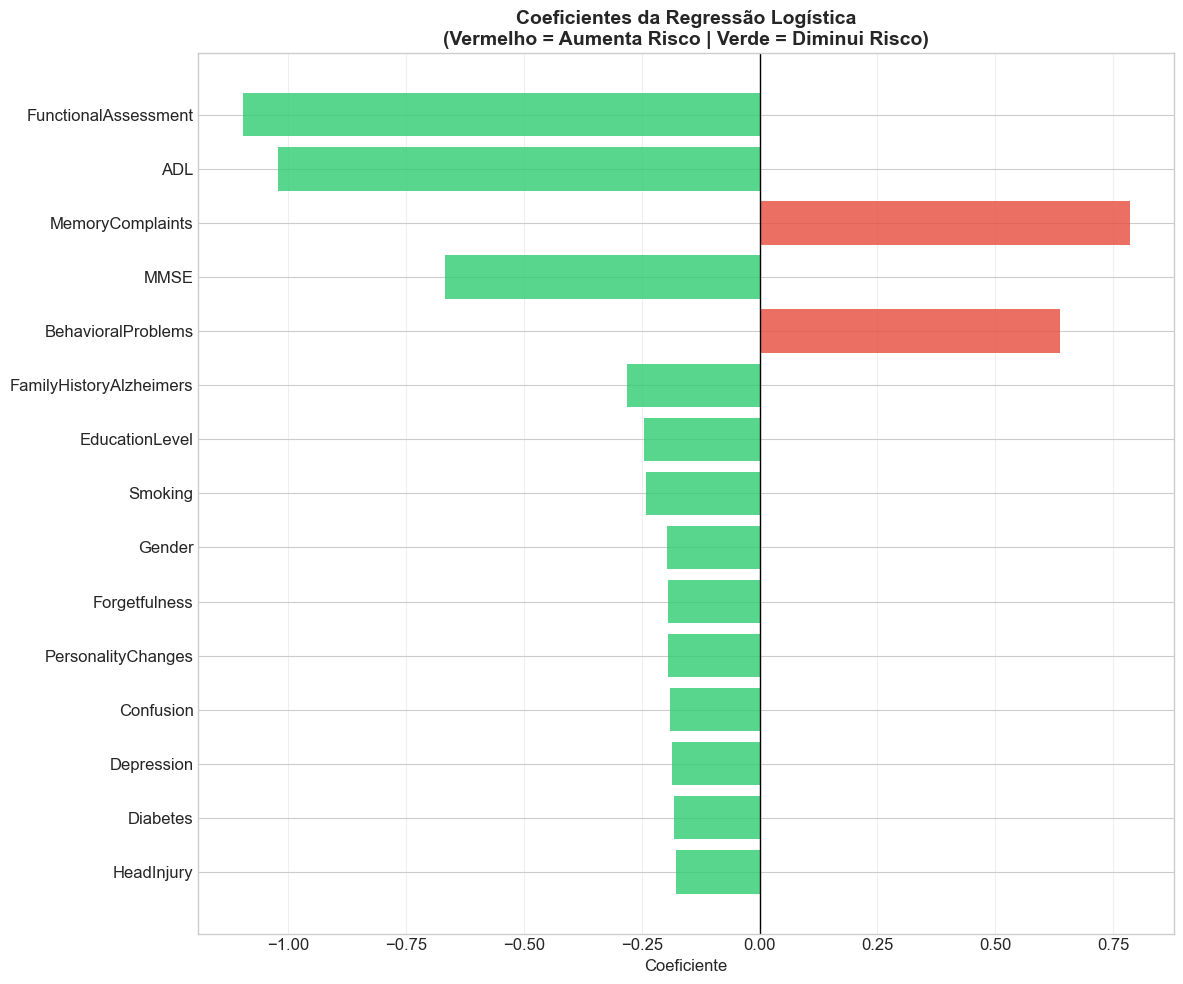

In [13]:
# ==============================================================================
# ANÁLISE DOS COEFICIENTES
# ==============================================================================

coeficientes = lr_otimizado.coef_[0]
intercept = lr_otimizado.intercept_[0]

# Ordenar por valor absoluto
indices = np.argsort(np.abs(coeficientes))[::-1]

print("=" * 60)
print("COEFICIENTES DA REGRESSÃO LOGÍSTICA")
print("=" * 60)
print(f"\nIntercept (β₀): {intercept:.4f}")
print(f"\nCoeficientes ordenados por importância:")

for i, idx in enumerate(indices[:15], 1):
    sinal = '+' if coeficientes[idx] > 0 else '-'
    efeito = 'aumenta risco' if coeficientes[idx] > 0 else 'diminui risco'
    print(f"  {i:2d}. {feature_names[idx]:30s}: {sinal}{abs(coeficientes[idx]):.4f} ({efeito})")

# Gráfico de coeficientes
plt.figure(figsize=(12, 10))

# Top 15 features mais importantes
top_n = 15
top_indices = indices[:top_n]

# Cores baseadas no sinal
colors = ['#e74c3c' if coeficientes[i] > 0 else '#2ecc71' for i in top_indices[::-1]]

plt.barh(range(top_n), coeficientes[top_indices][::-1], color=colors, alpha=0.8)
plt.yticks(range(top_n), [feature_names[i] for i in top_indices[::-1]])
plt.xlabel('Coeficiente', fontsize=12)
plt.axvline(x=0, color='black', linewidth=1)
plt.title('Coeficientes da Regressão Logística\n(Vermelho = Aumenta Risco | Verde = Diminui Risco)', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('lr_coeficientes.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Odds Ratios (Razão de Chances)

O **Odds Ratio** é a exponencial do coeficiente e indica:
- **OR > 1**: Feature aumenta as chances de Alzheimer
- **OR < 1**: Feature diminui as chances de Alzheimer
- **OR = 1**: Sem efeito

In [14]:
# ==============================================================================
# ODDS RATIOS
# ==============================================================================

odds_ratios = np.exp(coeficientes)

print("=" * 60)
print("ODDS RATIOS (RAZÃO DE CHANCES)")
print("=" * 60)

print("\nInterpretação: OR > 1 aumenta risco, OR < 1 diminui risco\n")

for i, idx in enumerate(indices[:10], 1):
    or_val = odds_ratios[idx]
    if or_val > 1:
        pct_change = (or_val - 1) * 100
        interp = f"+{pct_change:.1f}% de risco por unidade"
    else:
        pct_change = (1 - or_val) * 100
        interp = f"-{pct_change:.1f}% de risco por unidade"
    
    print(f"  {i:2d}. {feature_names[idx]:30s}: OR = {or_val:.4f} ({interp})")

ODDS RATIOS (RAZÃO DE CHANCES)

Interpretação: OR > 1 aumenta risco, OR < 1 diminui risco

   1. FunctionalAssessment          : OR = 0.3339 (-66.6% de risco por unidade)
   2. ADL                           : OR = 0.3602 (-64.0% de risco por unidade)
   3. MemoryComplaints              : OR = 2.1935 (+119.4% de risco por unidade)
   4. MMSE                          : OR = 0.5132 (-48.7% de risco por unidade)
   5. BehavioralProblems            : OR = 1.8936 (+89.4% de risco por unidade)
   6. FamilyHistoryAlzheimers       : OR = 0.7556 (-24.4% de risco por unidade)
   7. EducationLevel                : OR = 0.7828 (-21.7% de risco por unidade)
   8. Smoking                       : OR = 0.7863 (-21.4% de risco por unidade)
   9. Gender                        : OR = 0.8224 (-17.8% de risco por unidade)
  10. Forgetfulness                 : OR = 0.8228 (-17.7% de risco por unidade)


## 13. Matriz de Confusão e Curvas

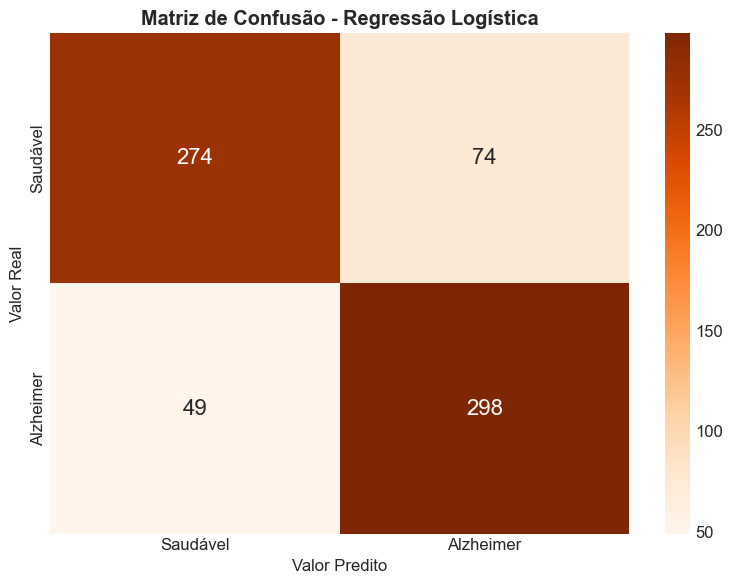

TN: 274, TP: 298, FP: 74, FN: 49


In [15]:
# ==============================================================================
# MATRIZ DE CONFUSÃO
# ==============================================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Saudável', 'Alzheimer'],
            yticklabels=['Saudável', 'Alzheimer'],
            annot_kws={'size': 16})
plt.title('Matriz de Confusão - Regressão Logística', fontweight='bold')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predito')
plt.tight_layout()
plt.savefig('lr_matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN: {tn}, TP: {tp}, FP: {fp}, FN: {fn}")

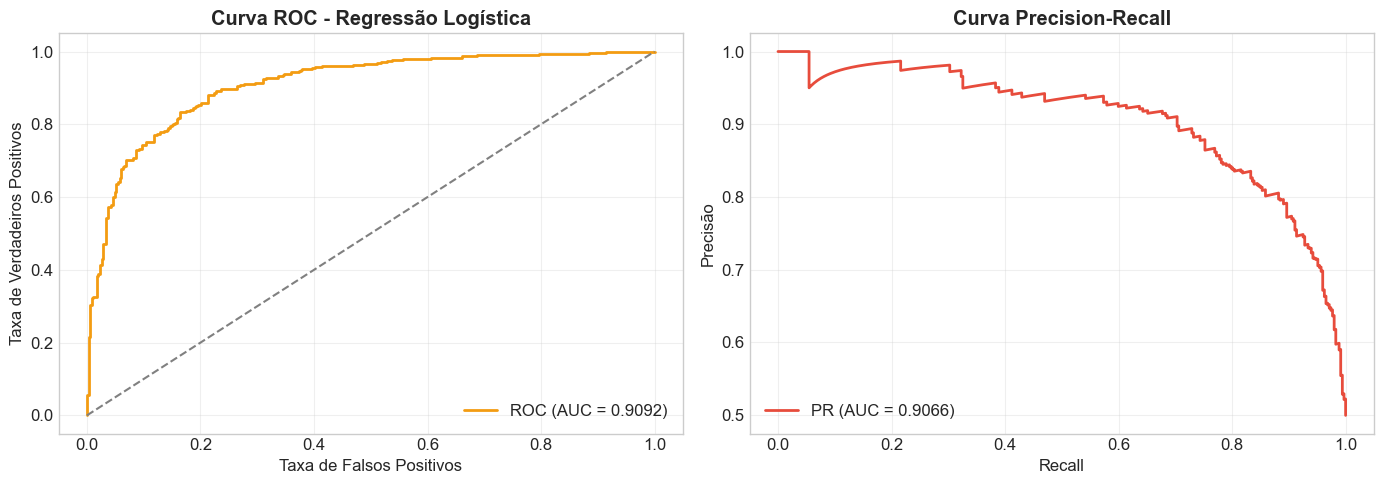

AUC-ROC: 0.9092
AUC-PR: 0.9066


In [16]:
# ==============================================================================
# CURVAS ROC E PRECISION-RECALL
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='#f39c12', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0].set_xlabel('Taxa de Falsos Positivos')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos')
axes[0].set_title('Curva ROC - Regressão Logística', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# PR
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_curve, precision_curve)

axes[1].plot(recall_curve, precision_curve, color='#e74c3c', lw=2, label=f'PR (AUC = {pr_auc:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precisão')
axes[1].set_title('Curva Precision-Recall', fontweight='bold')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lr_curvas_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC-ROC: {roc_auc:.4f}")
print(f"AUC-PR: {pr_auc:.4f}")

## 14. Análise de Diferentes Thresholds

In [17]:
# ==============================================================================
# ANÁLISE DE THRESHOLDS
# ==============================================================================

print("=" * 60)
print("ANÁLISE DE DIFERENTES THRESHOLDS")
print("=" * 60)

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

print(f"\n{'Threshold':<12} {'Acurácia':<12} {'Precisão':<12} {'Recall':<12} {'F1-Score':<12}")
print("-" * 60)

for thresh in thresholds:
    y_pred_thresh = (y_proba >= thresh).astype(int)
    acc = accuracy_score(y_test, y_pred_thresh)
    prec = precision_score(y_test, y_pred_thresh)
    rec = recall_score(y_test, y_pred_thresh)
    f1_t = f1_score(y_test, y_pred_thresh)
    
    print(f"   {thresh:<10} {acc*100:>9.2f}% {prec*100:>9.2f}% {rec*100:>9.2f}% {f1_t*100:>9.2f}%")

print("\nNota: Para diagnóstico médico, thresholds menores aumentam Recall")
print("(detecta mais casos de Alzheimer, mas com mais falsos positivos)")

ANÁLISE DE DIFERENTES THRESHOLDS

Threshold    Acurácia     Precisão     Recall       F1-Score    
------------------------------------------------------------
   0.3            78.13%     70.97%     95.10%     81.28%
   0.4            80.43%     74.94%     91.35%     82.34%
   0.5            82.30%     80.11%     85.88%     82.89%
   0.6            82.73%     83.68%     81.27%     82.46%
   0.7            81.87%     89.32%     72.33%     79.94%

Nota: Para diagnóstico médico, thresholds menores aumentam Recall
(detecta mais casos de Alzheimer, mas com mais falsos positivos)


## 15. Conclusão

In [18]:
# ==============================================================================
# RESUMO FINAL
# ==============================================================================

print("=" * 70)
print("RESUMO FINAL - REGRESSÃO LOGÍSTICA PARA DETECÇÃO DE ALZHEIMER")
print("=" * 70)

print(f"\nMelhores Hiperparâmetros:")
for param, value in grid_search.best_params_.items():
    print(f"  - {param}: {value}")

print(f"\nDesempenho Final:")
print(f"  - Acurácia:  {accuracy*100:.2f}%")
print(f"  - Precisão:  {precision*100:.2f}%")
print(f"  - Recall:    {recall*100:.2f}%")
print(f"  - F1-Score:  {f1*100:.2f}%")
print(f"  - AUC-ROC:   {roc_auc:.4f}")

print(f"\nTop 5 Fatores de Risco (Coeficientes mais fortes):")
for i, idx in enumerate(indices[:5], 1):
    efeito = '(+)' if coeficientes[idx] > 0 else '(-)'
    print(f"  {i}. {feature_names[idx]} {efeito}: {coeficientes[idx]:.4f}")

print("\n" + "=" * 70)
print("VANTAGENS DA REGRESSÃO LOGÍSTICA:")
print("=" * 70)
print("""
  1. INTERPRETABILIDADE: Coeficientes explicam o impacto de cada feature
  2. PROBABILÍSTICO: Retorna probabilidades, não apenas classes
  3. EFICIENTE: Treino rápido, mesmo em grandes datasets
  4. REGULARIZAÇÃO: L1, L2 ou Elastic Net para evitar overfitting
  5. BASELINE SÓLIDO: Ótimo para comparar com modelos mais complexos
""")

print("LIMITAÇÕES:")
print("""
  1. LINEARIDADE: Assume relação linear entre features e log-odds
  2. NÃO CAPTURA INTERAÇÕES: Precisa criar features manualmente
  3. SENSÍVEL A OUTLIERS: Pode afetar os coeficientes
  4. MULTICOLINEARIDADE: Features correlacionadas são problemáticas
""")

RESUMO FINAL - REGRESSÃO LOGÍSTICA PARA DETECÇÃO DE ALZHEIMER

Melhores Hiperparâmetros:
  - C: 0.1
  - class_weight: None
  - penalty: l2
  - solver: liblinear

Desempenho Final:
  - Acurácia:  82.30%
  - Precisão:  80.11%
  - Recall:    85.88%
  - F1-Score:  82.89%
  - AUC-ROC:   0.9092

Top 5 Fatores de Risco (Coeficientes mais fortes):
  1. FunctionalAssessment (-): -1.0968
  2. ADL (-): -1.0212
  3. MemoryComplaints (+): 0.7855
  4. MMSE (-): -0.6671
  5. BehavioralProblems (+): 0.6385

VANTAGENS DA REGRESSÃO LOGÍSTICA:

  1. INTERPRETABILIDADE: Coeficientes explicam o impacto de cada feature
  2. PROBABILÍSTICO: Retorna probabilidades, não apenas classes
  3. EFICIENTE: Treino rápido, mesmo em grandes datasets
  4. REGULARIZAÇÃO: L1, L2 ou Elastic Net para evitar overfitting
  5. BASELINE SÓLIDO: Ótimo para comparar com modelos mais complexos

LIMITAÇÕES:

  1. LINEARIDADE: Assume relação linear entre features e log-odds
  2. NÃO CAPTURA INTERAÇÕES: Precisa criar features manualm